In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [3]:
print(df.dtypes)

Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object


Сразу переведем столбец "Дата" в правильный формат

In [5]:
df['Дата']=pd.to_datetime(df['Дата'])
print(df.dtypes)

Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object


Сгруппируйте данные по дате, посчитайте количество продаж

In [6]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

Вывести несколько первых строк сгруппированных данных

In [7]:
print(grouped_df.head())

        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055


Нарисуйте график продаж у `grouped_df`

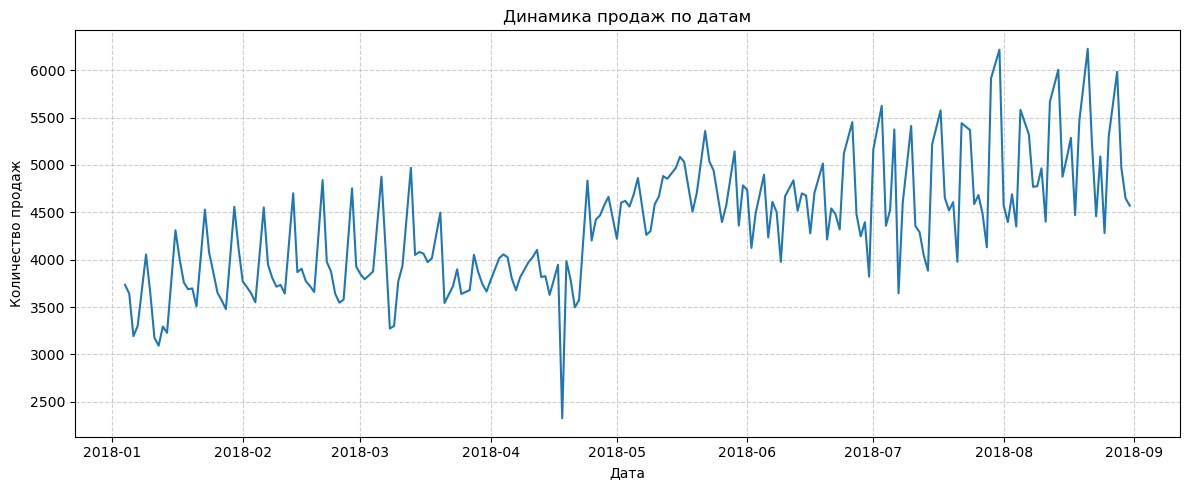

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(grouped_df['Дата'], grouped_df['Количество'], color='tab:blue', linewidth=1.5)
plt.title('Динамика продаж по датам')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

На протяжении всего периода (с января по август 2018 года) наблюдается устойчивый положительный рост объёма  продаж
Сезонность / цикличность: График имеет ярко выраженную цикличность с регулярными пиками и спадами продаж в определенные дни недели.
Аномалии и выбросы:
18 апреля 2018 года зафиксирован резкий провал (минимум продаж ~2 326 единиц).
В конце июля — начале августа 2018 года наблюдаются максимальные пиковые значения продаж

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [9]:
max_outlier_row = df.loc[df['Количество'].idxmax()]
print(max_outlier_row)

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [10]:
wedn_wareh3_summer_df = df[
    (df['Склад'] == 3) & 
    (df['Дата'].dt.dayofweek == 2) & 
    (df['Дата'].dt.month.isin([6, 7, 8]))
]

top_product = wedn_wareh3_summer_df.groupby('Номенклатура')['Количество'].sum().reset_index()
top_product = top_product.sort_values(by='Количество', ascending=False)

print(top_product.head(1))

  Номенклатура  Количество
1    product_1        2267


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [45]:
#Считываем первые 2 столбца файла погоды rp5
weather_df = pd.read_csv(
    'Weather Astana.csv', 
    skiprows=6, 
    sep=';', 
    encoding='cp1251', 
    header=None,
    usecols=[0, 1],
    on_bad_lines='skip'
)

#временные названия колонкам
weather_df.columns = ['Местное время', 'T']

print("Размерность исходного датафрейма (строк, столбцов)")
print(weather_df.shape)

print("\nПервые 5 строк исходных данных")
print(weather_df.head())

print("\nОбщая информация о структуре и типах данных (info)")
weather_df.info()

Размерность исходного датафрейма (строк, столбцов)
(1943, 2)

Первые 5 строк исходных данных
            Местное время     T
0  Местное время в Астане     T
1        31.08.2018 23:00   8.2
2        31.08.2018 20:00   9.6
3        31.08.2018 17:00  11.3
4        31.08.2018 14:00  12.3

Общая информация о структуре и типах данных (info)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1943 entries, 0 to 1942
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Местное время  1943 non-null   object
 1   T              1943 non-null   object
dtypes: object(2)
memory usage: 30.5+ KB


In [39]:
# Очищаем строки от кавычек
weather_df['Местное время'] = weather_df['Местное время'].astype(str).str.replace('"', '').str.replace("'", "").str.strip()
weather_df['T'] = weather_df['T'].astype(str).str.replace('"', '').str.replace("'", "").str.strip()

# Преобразуем температуру в числовой тип
weather_df['T'] = pd.to_numeric(weather_df['T'], errors='coerce')

# Переводим время в формат datetime
weather_df['Дата_dt'] = pd.to_datetime(weather_df['Местное время'], format='%d.%m.%Y %H:%M', errors='coerce').dt.floor('D')

print("Количество пропущенных значений до очистки")
print(weather_df.isnull().sum())

--- Количество пропущенных значений до очистки ---
Местное время    0
T                1
Дата_dt          1
dtype: int64


In [44]:
# Удаляем служебные/пустые строки
clean_weather = weather_df.dropna(subset=['Дата_dt', 'T']).copy()

# Группируем по дням и находим среднюю суточную температуру
daily_temp = clean_weather.groupby('Дата_dt')['T'].mean().reset_index()

print("\nОписательная статистика по температуре (describe)")
print(daily_temp['T'].describe())

print("\nПервые 5 строк обработанного датасета погоды")
daily_temp.head()


Описательная статистика по температуре (describe)
count    243.000000
mean       4.372891
std       15.578870
min      -34.662500
25%       -9.975000
50%        7.887500
75%       18.493750
max       27.100000
Name: T, dtype: float64

Первые 5 строк обработанного датасета погоды


,Дата_dt,T
0,2018-01-01,-9.4625
1,2018-01-02,-9.5125
2,2018-01-03,-11.4625
3,2018-01-04,-14.0750
4,2018-01-05,-16.8625


In [43]:
# 1. Загружаем датасет продаж
df = pd.read_csv('data.csv')

# 2. Приводим дату к дневному формату
df['Дата_dt'] = pd.to_datetime(df['Дата']).dt.floor('D')

# 3. Считаем суммарное количество продаж по дням
grouped_df = df.groupby('Дата_dt')['Количество'].sum().reset_index()

print("Информация о структуре сгруппированных продаж")
grouped_df.info()

print("\nПервые 5 строк датафрейма продаж")
grouped_df.head()

Информация о структуре сгруппированных продаж
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Дата_dt     205 non-null    datetime64[ns]
 1   Количество  205 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 3.3 KB

Первые 5 строк датафрейма продаж


,Дата_dt,Количество
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


In [42]:
# Объединяем данные продаж и погоды
merged_df = pd.merge(grouped_df, daily_temp, on='Дата_dt', how='inner')

print("Информация о совмещенном датафрейме (info)")
merged_df.info()

print("\nСтатистический обзор объединенных данных")
print(merged_df.describe())

print("\nПервые 5 строк объединенного датасета")
merged_df.head()

Информация о совмещенном датафрейме (info)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Дата_dt     205 non-null    datetime64[ns]
 1   Количество  205 non-null    int64         
 2   T           205 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 4.9 KB

Статистический обзор объединенных данных
                             Дата_dt   Количество           T
count                            205   205.000000  205.000000
mean   2018-05-03 16:58:32.195121920  4338.863415    4.579329
min              2018-01-04 00:00:00  2326.000000  -33.225000
25%              2018-03-04 00:00:00  3821.000000  -10.437500
50%              2018-05-04 00:00:00  4319.000000    8.112500
75%              2018-07-03 00:00:00  4702.000000   18.537500
max              2018-08-31 00:00:00  6226.000000   27.050000
std   

,Дата_dt,Количество,T
0,2018-01-04,3734,-14.0750
1,2018-01-05,3643,-16.8625
2,2018-01-06,3193,-13.3000
3,2018-01-07,3298,-12.7500
4,2018-01-09,4055,-6.2500


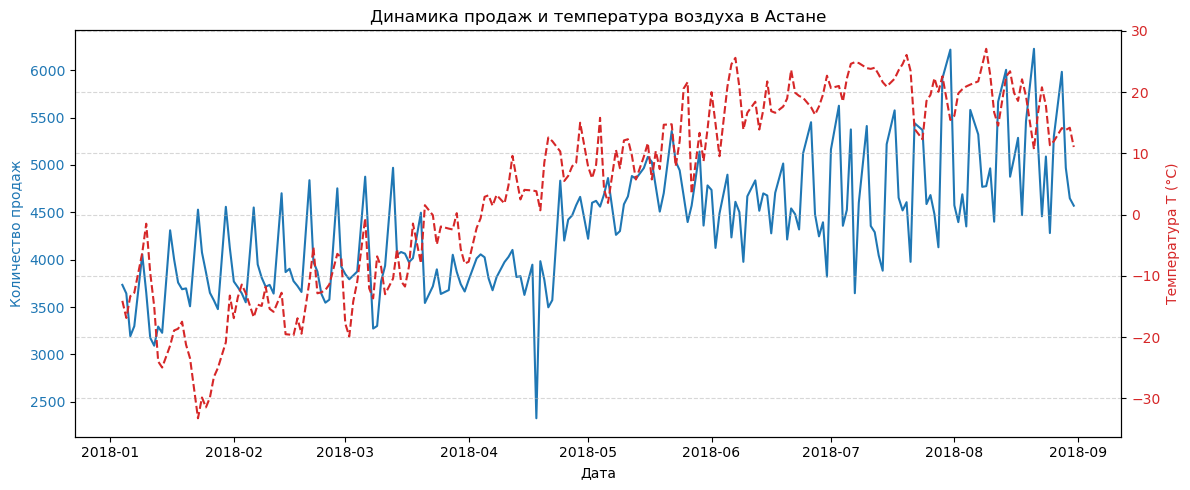

In [48]:
import matplotlib.pyplot as plt

# Совмещенный график (Продажи + Температура)
fig, ax1 = plt.subplots(figsize=(12, 5))

color = 'tab:blue'
ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество продаж', color=color)
ax1.plot(merged_df['Дата_dt'], merged_df['Количество'], color=color, linewidth=1.5)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Температура T (°C)', color=color)
ax2.plot(merged_df['Дата_dt'], merged_df['T'], color=color, linestyle='--', linewidth=1.5)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Динамика продаж и температура воздуха в Астане')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

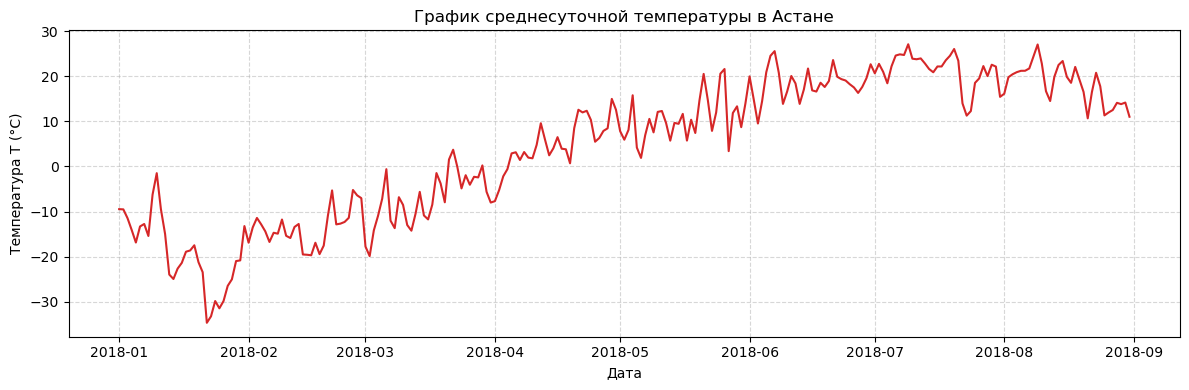

In [47]:
# График среднесуточной температуры
plt.figure(figsize=(12, 4))
plt.plot(daily_temp['Дата_dt'], daily_temp['T'], color='tab:red', linewidth=1.5)
plt.title('График среднесуточной температуры в Астане')
plt.xlabel('Дата')
plt.ylabel('Температура T (°C)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()